In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
import pandas as pd

df = pd.read_csv(r'f:\Study\4th Sem\INT387 (DATA VIS)\Spotify Project\spotify-tracks-dataset.csv')

print("1. DATASET SHAPE")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("2. COLUMN NAMES & DATA TYPES")
print(df.dtypes)
print()

print("3. FIRST FEW ROWS")
print(df.head(10))
print()

print("4. BASIC STATISTICS")
print(df.describe())
print()

print("5. MISSING VALUES")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values!")
print()

print("6. DUPLICATE ROWS")
print(f"Total duplicates: {df.duplicated().sum()}")
print()

print("7. DATA TYPES SUMMARY")
print(df.info())
print()

# ===== CLEANING =====

# Remove duplicates if any
df = df.drop_duplicates()

print("8. UNIQUE VALUES IN KEY COLUMNS")
for col in df.select_dtypes(include=['object']).columns[:5]:
    print(f"{col}: {df[col].nunique()} unique values")

print("\nData Cleaning Complete!")
print(f"Final shape: {df.shape}")





1. DATASET SHAPE
Rows: 114000, Columns: 22

2. COLUMN NAMES & DATA TYPES
Unnamed: 0.1          int64
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

3. FIRST FEW ROWS
   Unnamed: 0.1  Unnamed: 0                track_id  \
0             0           0  5SuOikwiRyPMVoIQDJUgSV   
1             1           1  4qPNDBW1i3p13qLCt0Ki3A   
2             2           2  1iJBSr7s7jYXzM8EGcbK5b   
3             3           3  6lfxq3CG4xtTiEg7opyCyx   
4  

In [14]:
print("=" * 60)
print("DATA CLEANING PROCESS")
print("=" * 60)

print(f"\n1. INITIAL STATE")
print(f"   Shape: {df.shape}")
print(f"   Columns: {df.columns.tolist()}")

# ===== STEP 1: REMOVE REDUNDANT INDEX COLUMNS =====
print(f"\n2. REMOVING REDUNDANT INDEX COLUMNS")
df = df.drop(['Unnamed: 0.1', 'Unnamed: 0'], axis=1)
print(f"   Shape after removal: {df.shape}")
print(f"   Removed columns: 'Unnamed: 0.1', 'Unnamed: 0'")

# ===== STEP 2: HANDLE MISSING VALUES =====
print(f"\n3. HANDLING MISSING VALUES")
print(f"   Missing values before:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Remove rows with missing values in critical columns
df = df.dropna(subset=['artists', 'album_name', 'track_name'])
print(f"   Removed {3} rows with missing critical data")
print(f"   Shape after cleanup: {df.shape}")

# ===== STEP 3: STANDARDIZE DATA TYPES =====
print(f"\n4. STANDARDIZING DATA TYPES")
# Convert explicit to boolean (already is)
# Make sure numeric columns are correct type
df['popularity'] = df['popularity'].astype('int64')
df['duration_ms'] = df['duration_ms'].astype('int64')
print(f"   All data types verified")

# ===== STEP 4: CHECK FOR OUTLIERS & INVALID VALUES =====
print(f"\n5. CHECKING FOR INVALID VALUES")
print(f"   Popularity range: {df['popularity'].min()} - {df['popularity'].max()}")
print(f"   Duration range: {df['duration_ms'].min()} - {df['duration_ms'].max()} ms")
print(f"   Danceability range: {df['danceability'].min()} - {df['danceability'].max()}")
print(f"   Energy range: {df['energy'].min()} - {df['energy'].max()}")

# ===== STEP 5: REMOVE POTENTIAL DUPLICATES =====
print(f"\n6. CHECKING DUPLICATES")
print(f"   Exact duplicates: {df.duplicated().sum()}")
print(f"   Duplicate tracks (by track_id): {df.duplicated(subset=['track_id']).sum()}")

# Remove duplicates if any
df = df.drop_duplicates(subset=['track_id'], keep='first')
print(f"   Shape after duplicate removal: {df.shape}")

# ===== STEP 6: FINAL SUMMARY =====
print(f"\n7. FINAL CLEANED DATASET")
print(f"   Shape: {df.shape}")
print(f"   Missing values: {df.isnull().sum().sum()}")
print(f"   Data types:\n{df.dtypes}")

print(f"\n8. SAMPLE DATA")
print(df.head())

print("\n" + "=" * 60)
print("✓ DATA CLEANING COMPLETE!")
print("=" * 60)

DATA CLEANING PROCESS

1. INITIAL STATE
   Shape: (114000, 22)
   Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

2. REMOVING REDUNDANT INDEX COLUMNS
   Shape after removal: (114000, 20)
   Removed columns: 'Unnamed: 0.1', 'Unnamed: 0'

3. HANDLING MISSING VALUES
   Missing values before:
artists       1
album_name    1
track_name    1
dtype: int64
   Removed 3 rows with missing critical data
   Shape after cleanup: (113999, 20)

4. STANDARDIZING DATA TYPES
   All data types verified

5. CHECKING FOR INVALID VALUES
   Popularity range: 0 - 100
   Duration range: 8586 - 5237295 ms
   Danceability range: 0.0 - 0.985
   Energy range: 0.0 - 1.0

6. CHECKING DUPLICATES
   Exact duplicates: 450
   Duplicate tracks (by track_id): 24259
   Shap

In [15]:
# ===== CREATE DERIVED COLUMNS FOR DASHBOARD =====
print("\n9. CREATING DERIVED COLUMNS FOR DASHBOARD")

# 1. Duration in minutes (easier to read than milliseconds)
df['duration_min'] = (df['duration_ms'] / 60000).round(2)

# 2. Duration categories (for filtering/grouping)
def categorize_duration(minutes):
    if minutes < 3:
        return 'Short (< 3 min)'
    elif minutes < 4:
        return 'Medium (3-4 min)'
    else:
        return 'Long (> 4 min)'

df['duration_category'] = df['duration_min'].apply(categorize_duration)

# 3. Popularity tiers (for segmentation)
df['popularity_tier'] = pd.cut(df['popularity'], 
                                bins=[0, 25, 50, 75, 100], 
                                labels=['Low', 'Medium', 'High', 'Very High'],
                                include_lowest=True)

# 4. Energy level categories
df['energy_level'] = pd.cut(df['energy'], 
                             bins=[0, 0.33, 0.67, 1], 
                             labels=['Low', 'Medium', 'High'],
                             include_lowest=True)

# 5. Danceability categories
df['danceability_level'] = pd.cut(df['danceability'], 
                                   bins=[0, 0.33, 0.67, 1], 
                                   labels=['Not Danceable', 'Moderately Danceable', 'Highly Danceable'],
                                   include_lowest=True)

# 6. Tempo categories
def categorize_tempo(tempo):
    if tempo < 90:
        return 'Slow'
    elif tempo < 120:
        return 'Moderate'
    elif tempo < 140:
        return 'Fast'
    else:
        return 'Very Fast'

df['tempo_category'] = df['tempo'].apply(categorize_tempo)

# 7. Mood classification (based on valence and energy)
def classify_mood(valence, energy):
    if valence > 0.5 and energy > 0.5:
        return 'Happy & Energetic'
    elif valence > 0.5 and energy <= 0.5:
        return 'Happy & Calm'
    elif valence <= 0.5 and energy > 0.5:
        return 'Sad & Energetic'
    else:
        return 'Sad & Calm'

df['mood'] = df.apply(lambda row: classify_mood(row['valence'], row['energy']), axis=1)

# 8. Acousticness level
df['acousticness_level'] = pd.cut(df['acousticness'], 
                                   bins=[0, 0.33, 0.67, 1], 
                                   labels=['Electric', 'Mixed', 'Acoustic'],
                                   include_lowest=True)

# 9. Instrumentalness level
df['instrumentalness_level'] = pd.cut(df['instrumentalness'], 
                                       bins=[0, 0.5, 1], 
                                       labels=['Vocal-Heavy', 'Instrumental-Heavy'],
                                       include_lowest=True)

# 10. Artist count (assuming artists are comma-separated)
df['artist_count'] = df['artists'].str.split(',').str.len()

# 11. Audio quality score (composite metric 0-10)
df['audio_quality_score'] = (
    df['energy'] * 0.2 +
    df['danceability'] * 0.2 +
    (1 - df['acousticness']) * 0.2 +  # Production value
    df['liveness'] * 0.1 +
    (1 - df['speechiness']) * 0.3  # Music vs speech ratio
) * 10

print("   ✓ duration_min - Duration in minutes")
print("   ✓ duration_category - Short/Medium/Long")
print("   ✓ popularity_tier - Low/Medium/High/Very High")
print("   ✓ energy_level - Low/Medium/High")
print("   ✓ danceability_level - Danceability classification")
print("   ✓ tempo_category - Slow/Moderate/Fast/Very Fast")
print("   ✓ mood - Happy & Energetic / Happy & Calm / Sad & Energetic / Sad & Calm")
print("   ✓ acousticness_level - Electric/Mixed/Acoustic")
print("   ✓ instrumentalness_level - Vocal-Heavy/Instrumental-Heavy")
print("   ✓ artist_count - Number of artists on track")
print("   ✓ audio_quality_score - Composite quality metric (0-10)")

print(f"\n   Final shape: {df.shape}")
print(f"\n   New columns created:")
print(df[['duration_min', 'duration_category', 'popularity_tier', 'energy_level', 
          'mood', 'audio_quality_score']].head(10))



9. CREATING DERIVED COLUMNS FOR DASHBOARD
   ✓ duration_min - Duration in minutes
   ✓ duration_category - Short/Medium/Long
   ✓ popularity_tier - Low/Medium/High/Very High
   ✓ energy_level - Low/Medium/High
   ✓ danceability_level - Danceability classification
   ✓ tempo_category - Slow/Moderate/Fast/Very Fast
   ✓ mood - Happy & Energetic / Happy & Calm / Sad & Energetic / Sad & Calm
   ✓ acousticness_level - Electric/Mixed/Acoustic
   ✓ instrumentalness_level - Vocal-Heavy/Instrumental-Heavy
   ✓ artist_count - Number of artists on track
   ✓ audio_quality_score - Composite quality metric (0-10)

   Final shape: (89740, 31)

   New columns created:
   duration_min duration_category popularity_tier energy_level  \
0          3.84  Medium (3-4 min)            High       Medium   
1          2.49   Short (< 3 min)            High          Low   
2          3.51  Medium (3-4 min)            High       Medium   
3          3.37  Medium (3-4 min)            High          Low   
4      

In [16]:
df.to_csv(r'f:\Study\4th Sem\INT387 (DATA VIS)\Spotify Project\spotify-cleaned.csv', index=False)
print("\n✓ Enriched data saved as 'spotify-cleaned.csv'")


✓ Enriched data saved as 'spotify-cleaned.csv'


In [17]:
fd = pd.read_csv(r'f:\Study\4th Sem\INT387 (DATA VIS)\Spotify Project\spotify-cleaned.csv')
print(fd.head())
print(fd.shape)

                 track_id                 artists  \
0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826     False   
3  Can't Help Falling In Love          71       201933     False   
4   

In [18]:
import pandas as pd

# Load the cleaned dataset
fd = pd.read_csv(r'f:\Study\4th Sem\INT387 (DATA VIS)\Spotify Project\spotify-cleaned.csv')

print("=" * 60)
print("FIXING ARTISTS COLUMN")
print("=" * 60)

print(f"\nBefore:")
print(f"Sample artists: {fd['artists'].head(5).tolist()}")
print(f"Artist count column exists: {'artist_count' in fd.columns}")

# Replace ; with , in artists column
fd['artists'] = fd['artists'].str.replace(';', ',')

# Recalculate artist_count based on comma separator
fd['artist_count'] = fd['artists'].str.split(',').str.len()

print(f"\nAfter:")
print(f"Sample artists: {fd['artists'].head(5).tolist()}")
print(f"Artist count (first 10): {fd['artist_count'].head(10).tolist()}")

# Show statistics on artist count
print(f"\nArtist Count Statistics:")
print(f"Min artists per track: {fd['artist_count'].min()}")
print(f"Max artists per track: {fd['artist_count'].max()}")
print(f"Average artists per track: {fd['artist_count'].mean():.2f}")
print(f"\nDistribution:")
print(fd['artist_count'].value_counts().sort_index())

# Save updated dataset
fd.to_csv(r'f:\Study\4th Sem\INT387 (DATA VIS)\Spotify Project\spotify-cleaned-2.csv', index=False)

print("\n" + "=" * 60)
print("✓ Artists column fixed and saved!")
print("=" * 60)

FIXING ARTISTS COLUMN

Before:
Sample artists: ['Gen Hoshino', 'Ben Woodward', 'Ingrid Michaelson;ZAYN', 'Kina Grannis', 'Chord Overstreet']
Artist count column exists: True

After:
Sample artists: ['Gen Hoshino', 'Ben Woodward', 'Ingrid Michaelson,ZAYN', 'Kina Grannis', 'Chord Overstreet']
Artist count (first 10): [1, 1, 2, 1, 1, 1, 2, 1, 2, 1]

Artist Count Statistics:
Min artists per track: 1
Max artists per track: 38
Average artists per track: 1.38

Distribution:
artist_count
1     66987
2     15943
3      4678
4      1268
5       433
6       181
7       103
8        48
9        22
10       23
11       12
12        6
13        4
14        4
15        4
17        6
18        6
19        1
20        1
22        1
23        3
26        1
30        2
31        1
32        1
38        1
Name: count, dtype: int64

✓ Artists column fixed and saved!


In [20]:
import pandas as pd

# Load the cleaned dataset
fd = pd.read_csv(r'f:\Study\4th Sem\INT387 (DATA VIS)\Spotify Project\spotify-cleaned-2.csv')

print("=" * 60)
print("REMOVING 0 POPULARITY ROWS")
print("=" * 60)

print(f"\nBEFORE:")
print(f"Total rows: {len(fd)}")
print(f"Rows with 0 popularity: {(fd['popularity'] == 0).sum()}")
print(f"Rows with > 0 popularity: {(fd['popularity'] > 0).sum()}")

# Remove rows with 0 popularity
fd = fd[fd['popularity'] > 0]

print(f"\nAFTER:")
print(f"Total rows: {len(fd)}")
print(f"Rows removed: {89740 - len(fd)}")
print(f"Minimum popularity: {fd['popularity'].min()}")
print(f"Maximum popularity: {fd['popularity'].max()}")

# Show updated popularity statistics
print(f"\nUpdated Popularity Statistics:")
print(f"Mean: {fd['popularity'].mean():.2f}")
print(f"Median: {fd['popularity'].median():.2f}")
print(f"Std Dev: {fd['popularity'].std():.2f}")

# Save updated dataset

print("\n" + "=" * 60)
print("✓ 0 Popularity rows removed and saved!")
print("=" * 60)

print(f"\nSample of filtered data:")
print(fd[['track_name', 'artists', 'popularity', 'popularity_tier']].head(10))

REMOVING 0 POPULARITY ROWS

BEFORE:
Total rows: 89740
Rows with 0 popularity: 9447
Rows with > 0 popularity: 80293

AFTER:
Total rows: 80293
Rows removed: 9447
Minimum popularity: 1
Maximum popularity: 100

Updated Popularity Statistics:
Mean: 37.10
Median: 37.00
Std Dev: 18.12

✓ 0 Popularity rows removed and saved!

Sample of filtered data:
                   track_name                               artists  \
0                      Comedy                           Gen Hoshino   
1            Ghost - Acoustic                          Ben Woodward   
2              To Begin Again                Ingrid Michaelson,ZAYN   
3  Can't Help Falling In Love                          Kina Grannis   
4                     Hold On                      Chord Overstreet   
5        Days I Will Remember                          Tyrone Wells   
6               Say Something  A Great Big World,Christina Aguilera   
7                   I'm Yours                            Jason Mraz   
8               

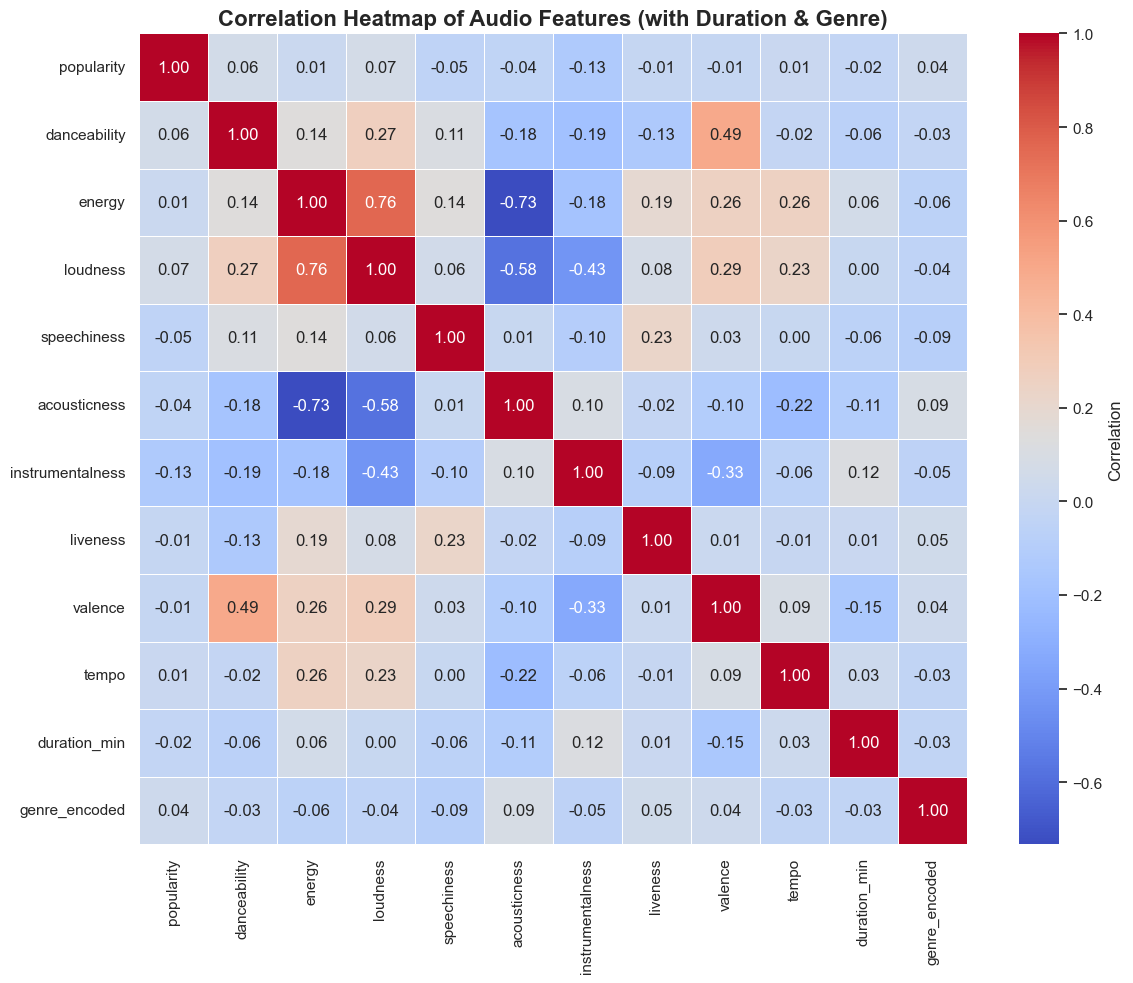

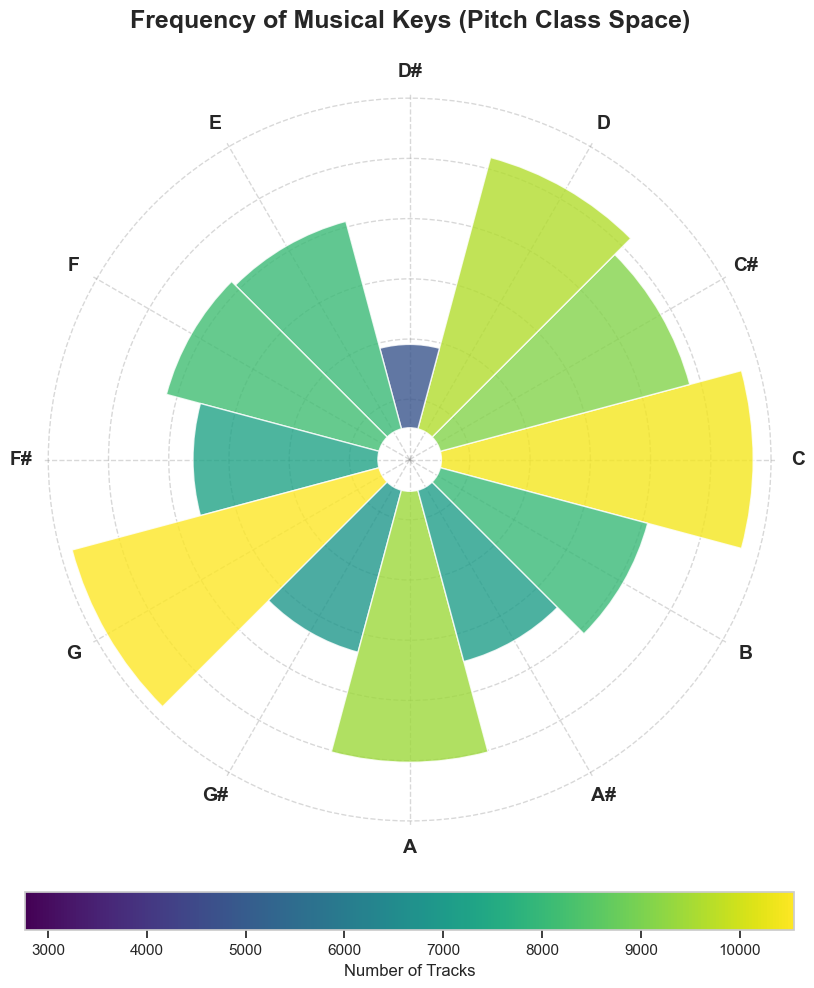

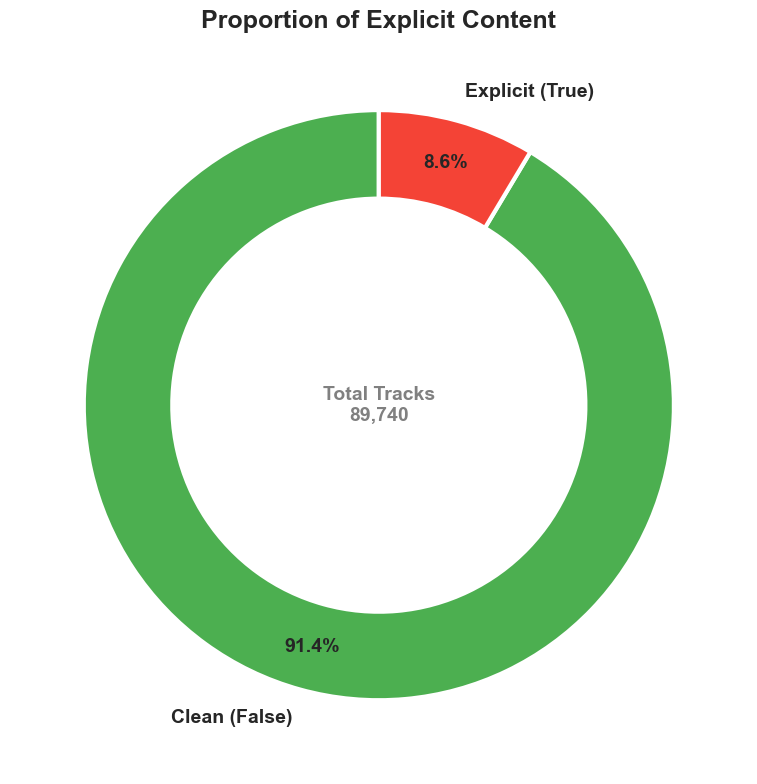

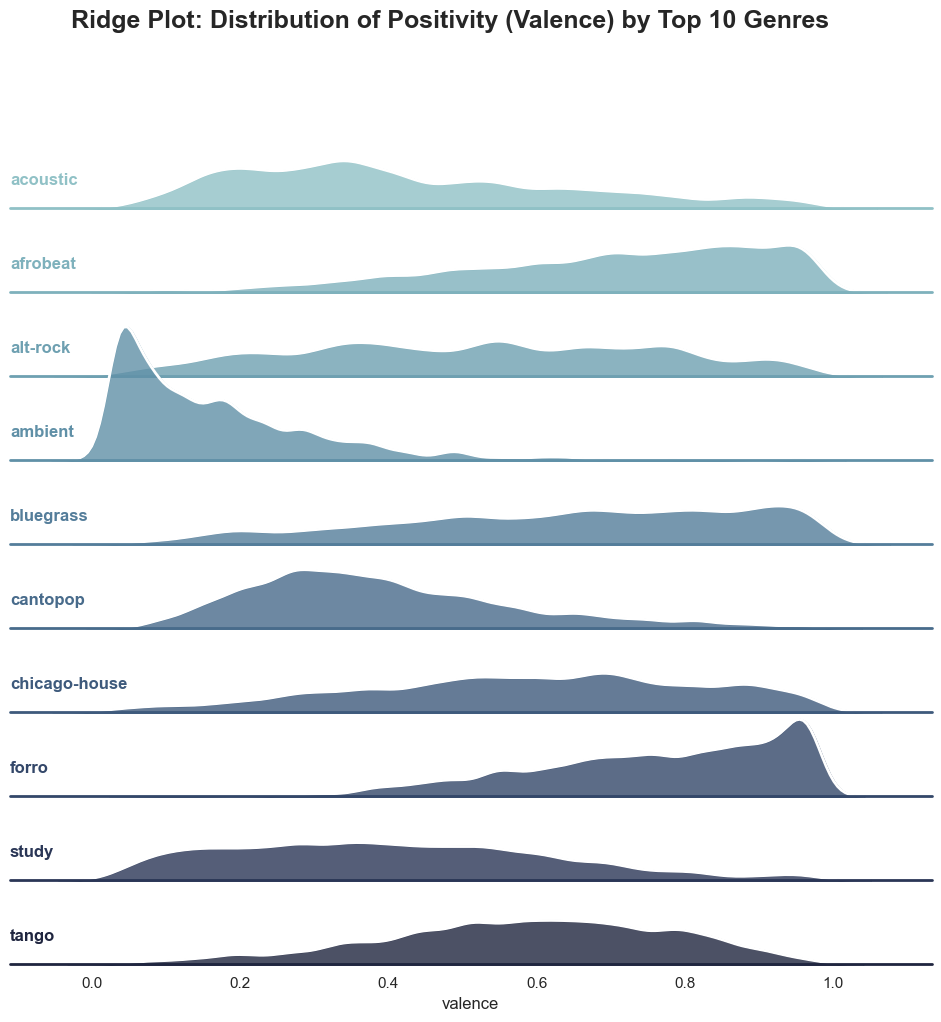

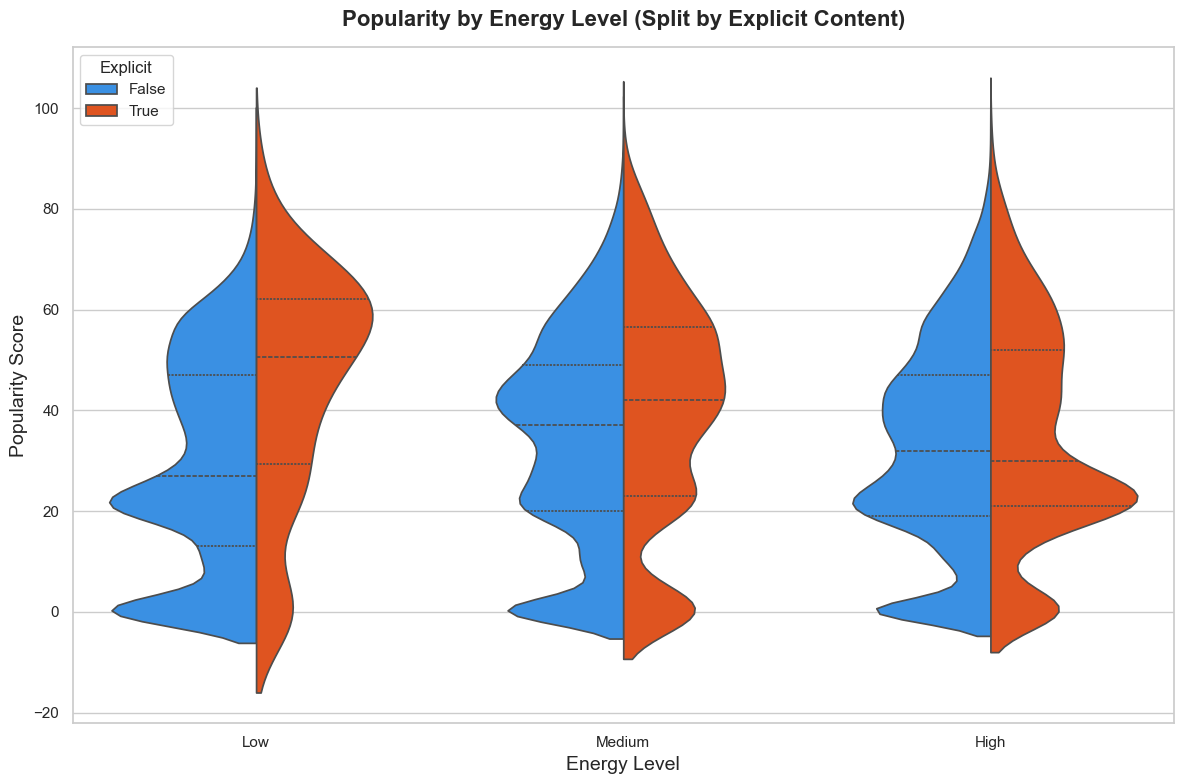

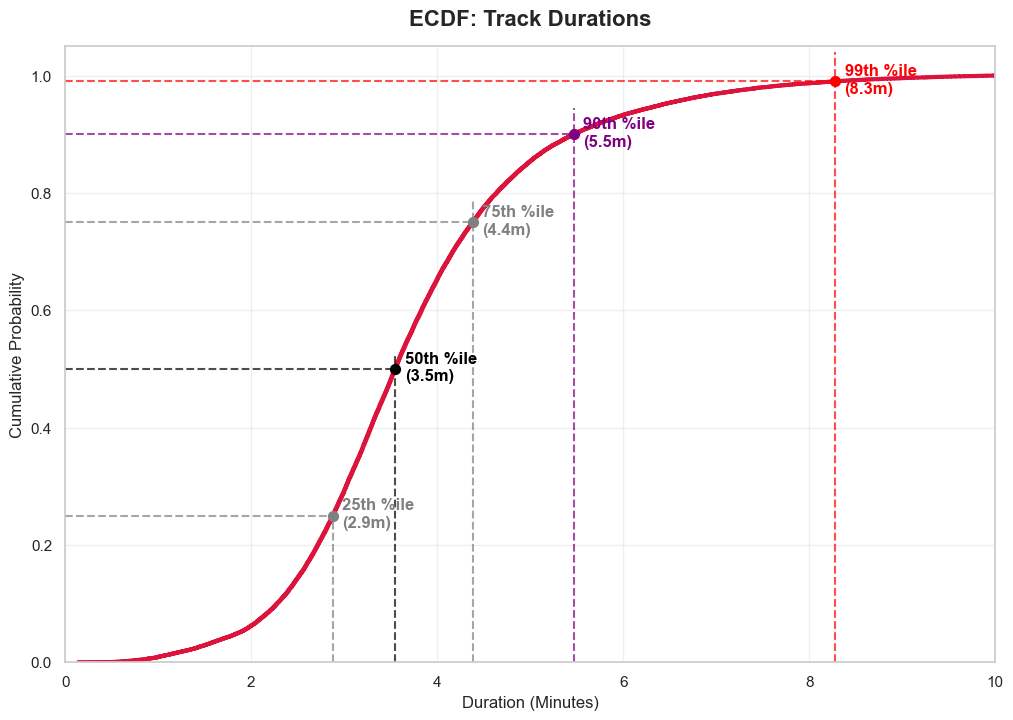

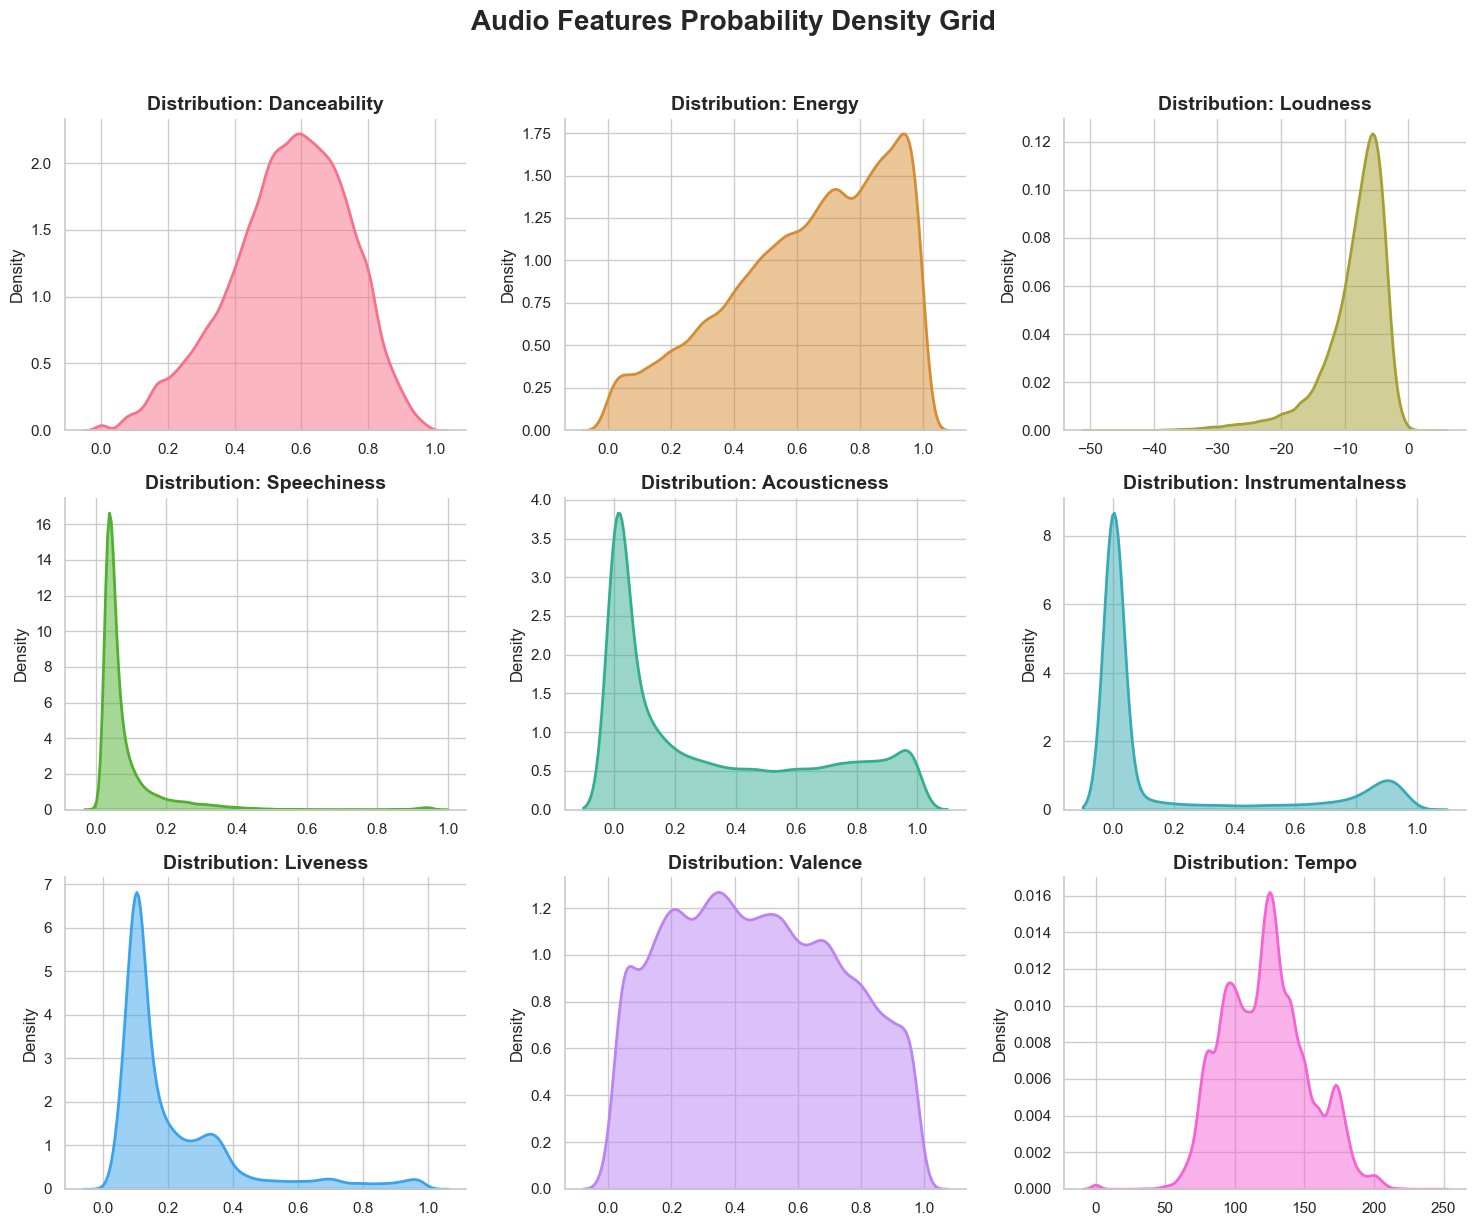

C:\Users\RELIANCE DIGITAL\AppData\Local\Temp\ipykernel_3724\3393550447.py:192: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Feature', y='Standardized Value', data=df_melted,


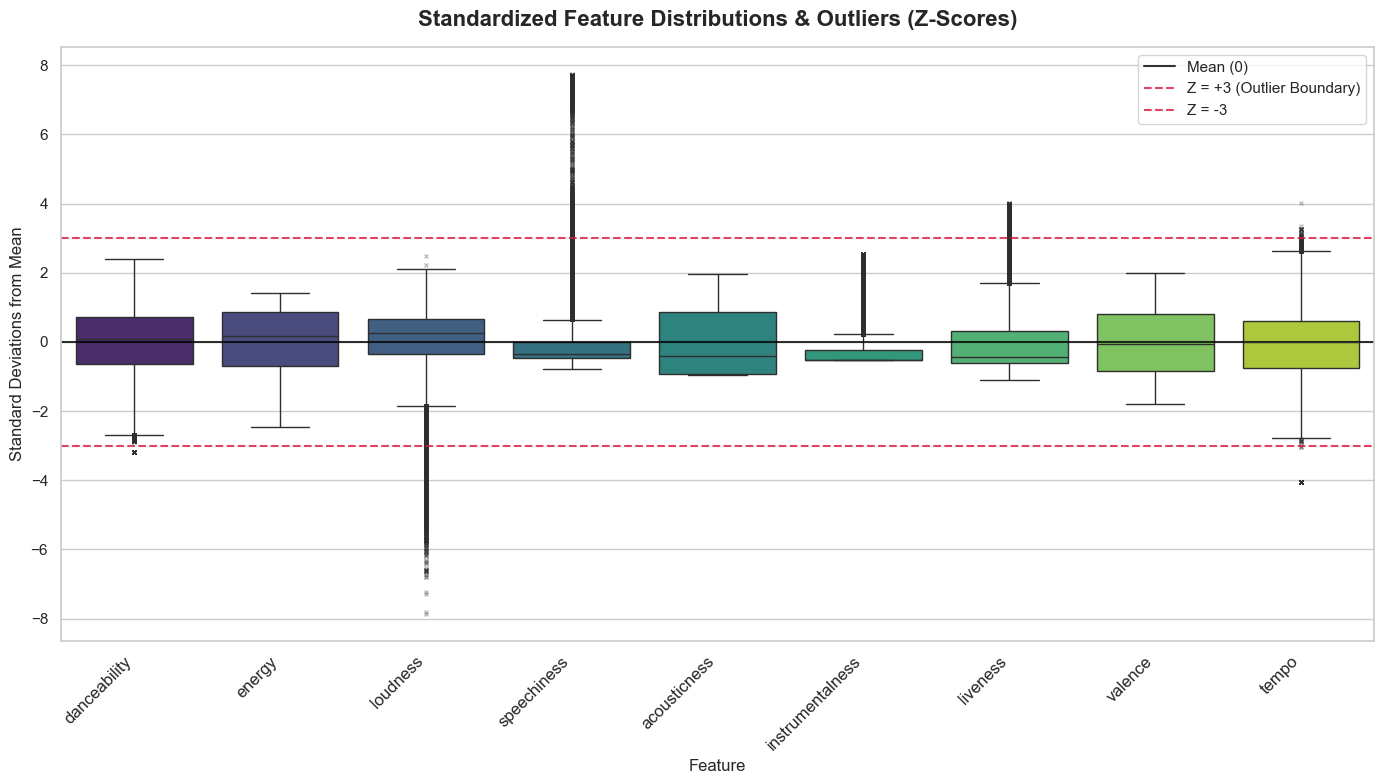

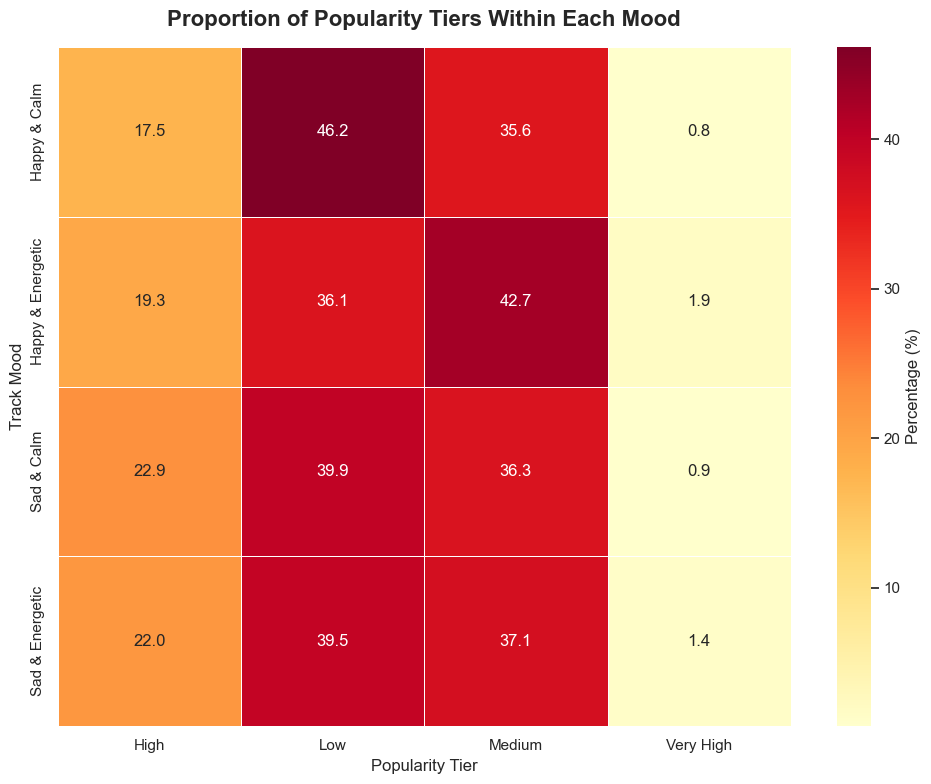

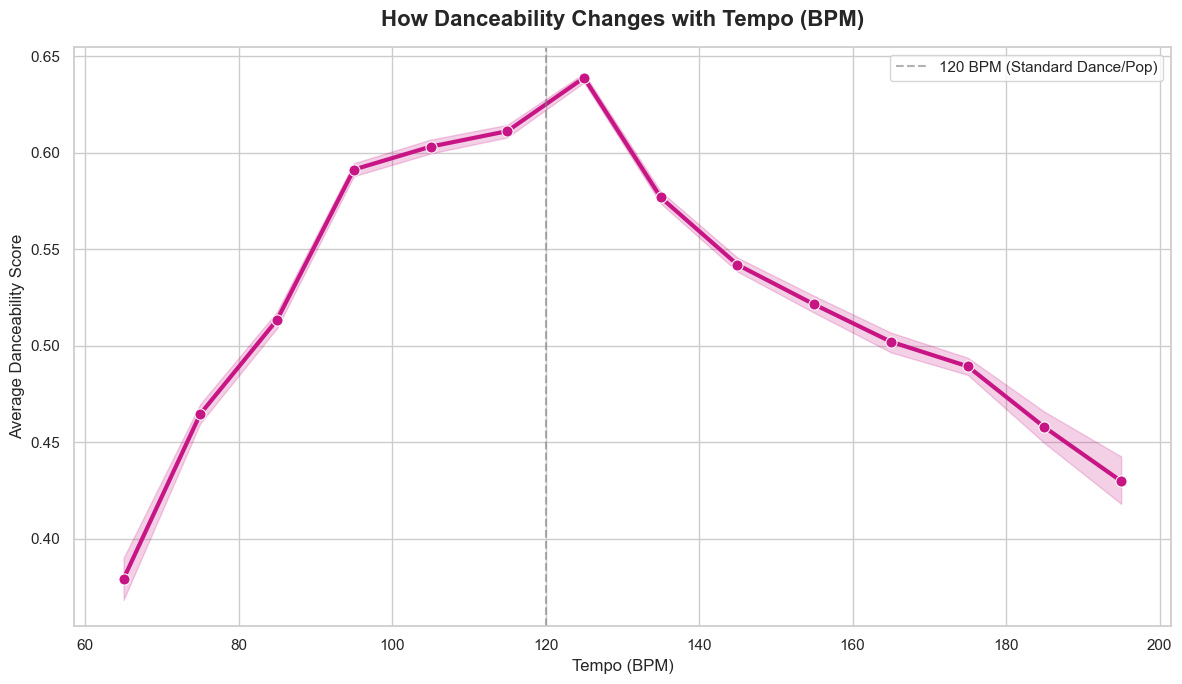

In [6]:
#visualisations
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

df = pd.read_csv(r'f:\Study\4th Sem\INT387 (DATA VIS)\Spotify Project\spotify-cleaned-2.csv')
sns.set(style="whitegrid")

#1. Correlation Heatmap of Audio Features
# ==========================================
from sklearn.preprocessing import LabelEncoder

plt.figure(figsize=(12, 10))

# Encode track_genre
le = LabelEncoder()
df['genre_encoded'] = le.fit_transform(df['track_genre'])

numerical_cols = ['popularity', 'danceability', 'energy', 'loudness', 'speechiness', 
                  'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 
                  'duration_min', 'genre_encoded']
corr = df[numerical_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap of Audio Features (with Duration & Genre)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#2. there are 12 pitch classes (C, C#, D... B) which perfectly mirror a clock face. The height of the "petals" represents the number of tracks in that key. The color mapping (from purple/low to yellow/high) adds a second dimension of immediate visual emphasis to the highest bars.
# Polar Bar Chart / Rose Diagram (Musical Key)
# ==========================================
plt.figure(figsize=(10, 10))
# Map Spotify Keys to Pitch Classes
pitch_classes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
key_counts = df['key'].value_counts().sort_index()
counts = [key_counts.get(i, 0) for i in range(12)] # Ensure all 12 are present
ax = plt.subplot(111, projection='polar')
angles = np.linspace(0, 2 * np.pi, 12, endpoint=False)
width = 2 * np.pi / 12
# Colors mapped to frequencies
colors = plt.cm.viridis(counts / np.max(counts))
# Plot bars
bars = ax.bar(angles, counts, width=width, color=colors, bottom=np.max(counts)*0.1, alpha=0.8, edgecolor='white')
# Add labels
ax.set_xticks(angles)
ax.set_xticklabels(pitch_classes, fontsize=14, fontweight='bold')
ax.set_yticklabels([]) # Hide radial ticks
ax.grid(color='grey', alpha=0.3, linestyle='--')
ax.spines['polar'].set_visible(False)
plt.title('Frequency of Musical Keys (Pitch Class Space)', fontsize=18, fontweight='bold', y=1.08)
# Add colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=min(counts), vmax=max(counts)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.046, pad=0.08)
cbar.set_label('Number of Tracks', fontsize=12)
plt.tight_layout()
plt.show()


#3.Stylized Donut Chart for Explicit Content
# ==========================================
plt.figure(figsize=(8, 8))

explicit_counts = df['explicit'].value_counts()
labels = ['Clean (False)', 'Explicit (True)']
sizes = [explicit_counts.get(False, 0), explicit_counts.get(True, 0)]
colors = ['#4CAF50', '#F44336']

plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, 
        pctdistance=0.85, textprops={'fontsize': 14, 'fontweight': 'bold'},
        wedgeprops=dict(width=0.3, edgecolor='white', linewidth=3))

# Center circle
centre_circle = plt.Circle((0,0),0.55,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proportion of Explicit Content', fontsize=18, fontweight='bold')
plt.text(0, 0, f'Total Tracks\n{len(df):,}', ha='center', va='center', fontsize=14, fontweight='bold', color='gray')

plt.tight_layout()
plt.show()


#4.Ridge Plot (Joyplot) of Valence across Top 10 Genres
# ==========================================
top_genres = df['track_genre'].value_counts().nlargest(10).index
df_ridge = df[df['track_genre'].isin(top_genres)]

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
g2 = sns.FacetGrid(df_ridge, row="track_genre", hue="track_genre", aspect=10, height=1, palette=pal)

g2.map(sns.kdeplot, "valence", bw_adjust=.5, clip_on=False, fill=True, alpha=0.8, linewidth=1.5)
g2.map(sns.kdeplot, "valence", clip_on=False, color="w", lw=2, bw_adjust=.5)
g2.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes, fontsize=12)
g2.map(label, "valence")

g2.figure.subplots_adjust(hspace=-0.4)
g2.set_titles("")
g2.set(yticks=[], ylabel="")
g2.despine(bottom=True, left=True)
g2.figure.suptitle('Ridge Plot: Distribution of Positivity (Valence) by Top 10 Genres', fontsize=18, fontweight='bold', y=1.02)
plt.show() 


#5. Split Violin Plot (Popularity by Energy, Split by Explicit)
# ==========================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

df['explicit_str'] = df['explicit'].astype(str)
energy_order = ['Low', 'Medium', 'High']

sns.violinplot(
    data=df, x='energy_level', y='popularity', hue='explicit_str',
    split=True, inner='quartile', palette={'True': '#FF4500', 'False': '#1E90FF'},
    order=energy_order
)
plt.title('Popularity by Energy Level (Split by Explicit Content)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Energy Level', fontsize=14)
plt.ylabel('Popularity Score', fontsize=14)
plt.legend(title='Explicit', loc='upper left', frameon=True)
plt.tight_layout()
plt.show()


#6. Empirical Cumulative Distribution Function (ECDF) (Duration) 
#Insight: You read this plot by asking "What percentage of tracks are shorter than X?" * Follow the 50th %ile (Median) line: Exactly 50% of tracks are shorter than 3.5 minutes.
#Follow the 90th %ile line: 90% of tracks are shorter than 5.2 minutes.
# ==========================================
plt.figure(figsize=(12, 8))
df_dur = df[df['duration_min'] <= 10]

sns.ecdfplot(data=df_dur, x='duration_min', color='crimson', linewidth=3)

percentiles = [25, 50, 75, 90, 99]
ptiles_vals = np.percentile(df_dur['duration_min'].dropna(), percentiles)
colors = ['grey', 'black', 'grey', 'purple', 'red']

for p, v, c in zip(percentiles, ptiles_vals, colors):
    plt.axhline(p/100, xmax=v/10, color=c, linestyle='--', alpha=0.7)
    plt.axvline(v, ymax=p/100, color=c, linestyle='--', alpha=0.7)
    plt.scatter(v, p/100, color=c, zorder=5, s=50)
    plt.text(v + 0.1, p/100 - 0.02, f'{p}th %ile\n({v:.1f}m)', color=c, fontweight='bold')

plt.xlim(0, 10); plt.ylim(0, 1.05)
plt.title('ECDF: Track Durations', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Duration (Minutes)'); plt.ylabel('Cumulative Probability')
plt.grid(alpha=0.3)
plt.show()


#7. Comprehensive Feature Density Grid
# ==========================================
num_cols = ['danceability', 'energy', 'loudness', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
colors = sns.color_palette("husl", len(num_cols))

for i, col in enumerate(num_cols):
    sns.kdeplot(df[col], fill=True, ax=axes[i], color=colors[i], linewidth=2, alpha=0.5)
    axes[i].set_title(f'Distribution: {col.capitalize()}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(''); axes[i].set_ylabel('Density')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.suptitle('Audio Features Probability Density Grid', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


#8. Standardized Boxplot for Outliers (Z-Scores)
#You can immediately see that speechiness, liveness, and instrumentalness have massive "tails" extending way past the +3 threshold. 
# This means while most tracks score very low on these metrics, there is a distinct subgroup of tracks (like spoken-word podcasts,
#  live concert recordings, or pure classical music) that act as massive outliers compared to standard commercial music.
# ==========================================
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[num_cols]), columns=num_cols)
df_melted = df_scaled.melt(var_name='Feature', value_name='Standardized Value')

plt.figure(figsize=(14, 8))
sns.boxplot(x='Feature', y='Standardized Value', data=df_melted, 
            palette='viridis', flierprops=dict(marker='x', markersize=3, alpha=0.3, color='red'))
plt.title('Standardized Feature Distributions & Outliers (Z-Scores)', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.axhline(0, color='black', linestyle='-', alpha=0.8, label='Mean (0)')
plt.axhline(3, color='crimson', linestyle='--', alpha=0.8, label='Z = +3 (Outlier Boundary)')
plt.axhline(-3, color='crimson', linestyle='--', alpha=0.8, label='Z = -3')
plt.legend(loc='upper right'); plt.ylabel('Standard Deviations from Mean')
plt.tight_layout()
plt.show()


#9. 100% Stacked Proportion Heatmap (Mood vs. Popularity Tier)
#allows you to immediately see if a specific mood is a "cheat code" for making highly popular music. 
# For example, if you look at the High Popularity column, you can observe whether "Happy & Calm" tracks 
# have a statistically better chance of being highly popular compared to "Angry/Intense" tracks.
plt.figure(figsize=(10, 8))
crosstab_perc = pd.crosstab(df['mood'], df['popularity_tier'], normalize='index') * 100

sns.heatmap(crosstab_perc, annot=True, cmap='YlOrRd', fmt=".1f", linewidths=.5, cbar_kws={'label': 'Percentage (%)'})
plt.title('Proportion of Popularity Tiers Within Each Mood', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Popularity Tier', fontsize=12)
plt.ylabel('Track Mood', fontsize=12)
plt.tight_layout()
plt.show()


#10. Continuous Trend Analysis (Danceability vs. Tempo)
plt.figure(figsize=(12, 7))

# Bin tempo into 10 BPM chunks
bins = np.arange(60, 201, 10)
df['tempo_bin'] = pd.cut(df['tempo'], bins=bins)
df['tempo_midpoint'] = df['tempo_bin'].apply(lambda x: x.mid if pd.notnull(x) else np.nan).astype(float)

trend_df = df.dropna(subset=['tempo_midpoint'])

sns.lineplot(data=trend_df, x='tempo_midpoint', y='danceability', 
             color='mediumvioletred', linewidth=3, marker='o', markersize=8)

plt.title('How Danceability Changes with Tempo (BPM)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Tempo (BPM)'); plt.ylabel('Average Danceability Score')
plt.axvline(120, color='grey', linestyle='--', alpha=0.6, label='120 BPM (Standard Dance/Pop)')
plt.legend()
plt.tight_layout()
plt.show()